<a href="https://colab.research.google.com/github/iking919/Detecting_Financial_Fraud_via_GNNs/blob/EDA/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecting Financial Fraud via Graph Neural Networks: A Multi-Dataset, Graph-Based Learning Approach

### Haoyuan Chen, Izaak King, Bryan Gelnett

# Data Exploration


## Dataset Preparation

First, we upload access the Kaggle API by uploading our `kaggle.json` file. This will allow us to easily download our datasets into our Colab session.

In [ ]:
from google.colab import files

files.upload() # Upload kaggle.json file into Colab session

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

To maintain a clean repository structure, we will download all datasets into a dedicated `data/` directory. Each dataset will have its own subfolder.

In [ ]:
import os

# Create a base directory for all data
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Data directory created at: {DATA_DIR}")

Data directory created at: ./data


### 1. PaySim Mobile Money Dataset
Link: https://www.kaggle.com/datasets/ealaxi/paysim1

In [ ]:
!kaggle datasets download -d ealaxi/paysim1 -p {DATA_DIR}/paysim --unzip
print("PaySim dataset downloaded and unzipped successfully.")

### 2. IEEE-CIS Fraud Detection Dataset
Link: https://www.kaggle.com/datasets/lnasiri007/ieeecis-fraud-detection

In [ ]:
!kaggle datasets download -d lnasiri007/ieeecis-fraud-detection -p {DATA_DIR}/ieee-cis --unzip
print("IEEE-CIS Fraud Detection dataset downloaded and unzipped successfully.")

### 3. Elliptic Data Set
Link: https://www.kaggle.com/datasets/ellipticco/elliptic-data-set

In [ ]:
!kaggle datasets download -d ellipticco/elliptic-data-set -p {DATA_DIR}/elliptic --unzip
print("Elliptic Data Set downloaded and unzipped successfully.")

## Introduction

Financial fraud remains a critical challenge in the modern digital economy, necessitating advanced detection mechanisms. Traditional machine learning models often evaluate transactions in isolation, neglecting the  complex relationships between entities.

This project leverages **Graph Neural Networks (GNNs)** to reframe fraud detection as a node/edge classification problem within transaction networks. By modeling entities (e.g., users, bank accounts) as nodes and transactions as edges, GNNs can capture structural and network patterns indicative of fraudulent behavior that tabular models might miss.


### Datasets
We evaluate our approach across three diverse financial datasets:
1. **PaySim Mobile Money Dataset**: A synthetic dataset simulating mobile money transactions, designed to mimic normal and malicious behavior in mobile financial services.
2. **IEEE-CIS Fraud Detection Dataset**: A real-world e-commerce transaction dataset containing categorical and numerical features associated with online card transactions.
3. **Elliptic Data Set**: A network of Bitcoin transactions, explicitly structured as a graph, where nodes represent transactions and edges represent the flow of Bitcoin, with nodes labeled as illicit or licit.

### Importing Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Datasets

We load the PaySim, IEEE-CIS, and Elliptic datasets into pandas DataFrames.


In [ ]:
df_paysim = pd.read_csv('./data/paysim/PS_20174392719_1491204439457_log.csv')
print("PaySim Shape:", df_paysim.shape)
display(df_paysim.head())

df_ieee_trans = pd.read_csv('./data/ieee-cis/train_transaction.csv')
df_ieee_id = pd.read_csv('./data/ieee-cis/train_identity.csv')
print("\nIEEE Transaction Shape:", df_ieee_trans.shape)
display(df_ieee_trans.head())
print("\nIEEE Identity Shape:", df_ieee_id.shape)
display(df_ieee_id.head())

df_elliptic_features = pd.read_csv('./data/elliptic/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header=None)
df_elliptic_edges = pd.read_csv('./data/elliptic/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')
df_elliptic_classes = pd.read_csv('./data/elliptic/elliptic_bitcoin_dataset/elliptic_txs_classes.csv')
print("\nElliptic Features Shape:", df_elliptic_features.shape)
display(df_elliptic_features.head())
print("\nElliptic Edges Shape:", df_elliptic_edges.shape)
display(df_elliptic_edges.head())
print("\nElliptic Classes Shape:", df_elliptic_classes.shape)
display(df_elliptic_classes.head())

PaySim Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



IEEE Transaction Shape: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



IEEE Identity Shape: (144233, 41)


...

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117



Elliptic Edges Shape: (234355, 2)


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206



Elliptic Classes Shape: (203769, 2)


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


## IEEE-CIS Exploration and Graph Design

We explore IEEE-CIS fraud distribution and missing values, and define its Graph Design.

In [ ]:
print("IEEE-CIS Fraud Distribution:\n", df_ieee_trans['isFraud'].value_counts(normalize=True) * 100)

print("\nTop 5 columns with most missing values in IEEE-CIS Transactions:")
print((df_ieee_trans.isnull().sum() / len(df_ieee_trans) * 100).sort_values(ascending=False).head())

print("\nTop 5 columns with most missing values in IEEE-CIS Identity:")
print((df_ieee_id.isnull().sum() / len(df_ieee_id) * 100).sort_values(ascending=False).head())


IEEE-CIS Fraud Distribution:
 isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

Top 5 columns with most missing values in IEEE-CIS Transactions:
dist2    93.628374
D7       93.409930
D13      89.509263
D14      89.469469
D12      89.041047
dtype: float64

Top 5 columns with most missing values in IEEE-CIS Identity:
id_24    96.708798
id_25    96.441868
id_07    96.425922
id_08    96.425922
id_21    96.423149
dtype: float64


### Visualization of Transaction Types

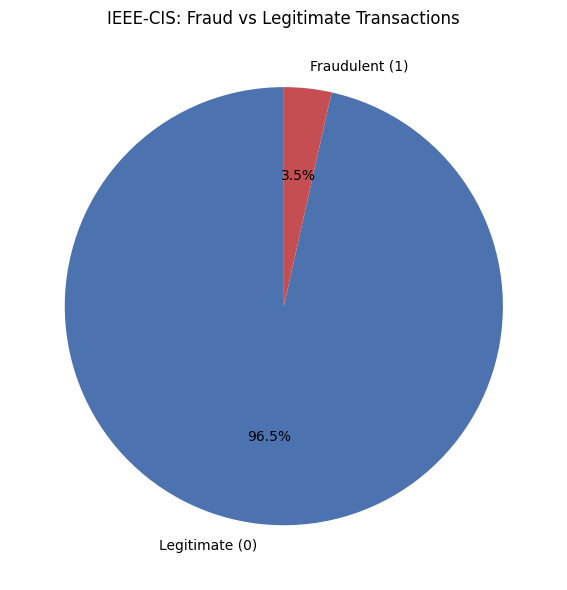

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# IEEE-CIS Fraud Distribution
ieee_counts = df_ieee_trans['isFraud'].value_counts()
axes[0].pie(ieee_counts, labels=['Legitimate (0)', 'Fraudulent (1)'], autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#C44E52'])
axes[0].set_title('IEEE-CIS: Fraud vs Legitimate Transactions')

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(ieee_counts, labels=['Legitimate (0)', 'Fraudulent (1)'], autopct='%1.1f%%', startangle=90, colors=['#4C72B0', '#C44E52'])
ax.set_title('IEEE-CIS: Fraud vs Legitimate Transactions')
plt.tight_layout()
plt.show()

From this visualization we see the heavy majority (96.5%) of transactions are legitimate, while only 3.5% are fraudulent. It is expected that legitimate transactions will dominate.

### PaySim Transaction Amount Distribution

We visualize the distribution of transaction amounts in the PaySim dataset, differentiating between fraudulent and non-fraudulent transactions, using histogram with KDE overlay

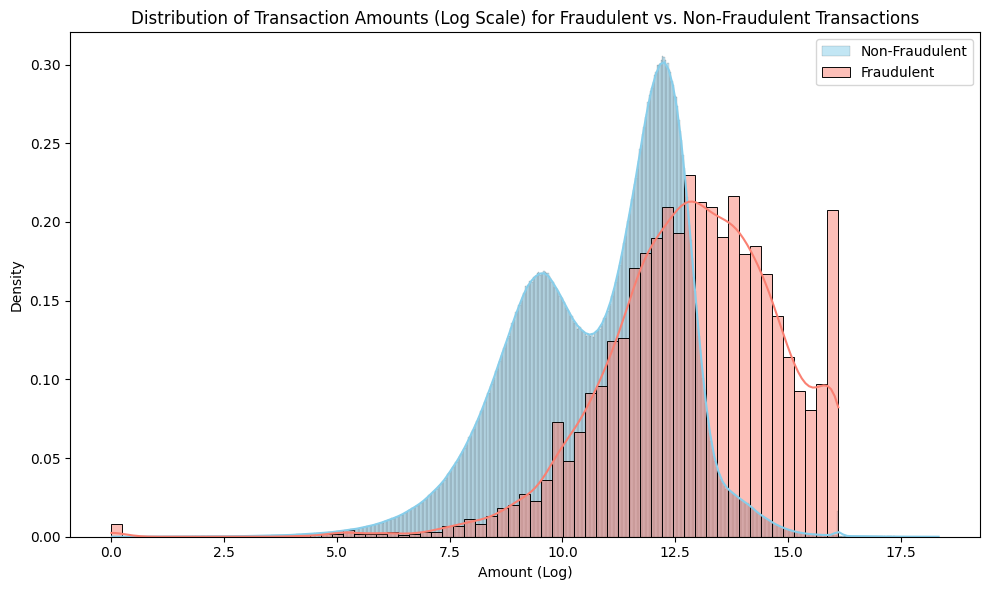

In [ ]:
# Filter the df_paysim DataFrame and create explicit copies
df_paysim_fraud = df_paysim[df_paysim['isFraud'] == 1].copy()
df_paysim_nonfraud = df_paysim[df_paysim['isFraud'] == 0].copy()

# Apply a log transformation to the 'amount' column
df_paysim_fraud['log_amount'] = np.log1p(df_paysim_fraud['amount'])
df_paysim_nonfraud['log_amount'] = np.log1p(df_paysim_nonfraud['amount'])

# Create a single figure with a histogram with KDE overlay
plt.figure(figsize=(10, 6))
sns.histplot(df_paysim_nonfraud['log_amount'], color='skyblue', label='Non-Fraudulent', kde=True, stat='density', alpha=0.5)
sns.histplot(df_paysim_fraud['log_amount'], color='salmon', label='Fraudulent', kde=True, stat='density', alpha=0.5)

plt.title('Distribution of Transaction Amounts (Log Scale) for Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Amount (Log)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

Based on this visualization we see that fraudulent activities tend to feature larger amounts than non-fraudulent activities. There is higher variance in transactions that are non-fraudulent with both smaller amounts and larger, while most fraudulent activities are higher amounts.

### Heterogeneous Graph Design for IEEE-CIS

While the IEEE-CIS dataset naturally supports a heterogeneous graph structure due to the presence of multiple entity types (e.g., transactions, cards, devices, and email domains), standard Graph Neural Network architectures such as GCN, GAT, and GraphSAGE require a homogeneous graph representation. To ensure compatibility with these models while still leveraging relational information, we transform the dataset into a transaction-level graph.

In this representation, each node corresponds to a transaction, which is the primary unit of interest for fraud classification. Node features include transaction-specific attributes such as transaction amount, timestamp, product code, and other engineered features derived from the original dataset.

Node Definition:

*  Transaction: Each node represents a single transaction, containing all relevant numerical and encoded categorical features. The task is to classify each node as fraudulent or non-fraudulent.

Edge Construction (Relationships):
Edges are defined between transactions based on shared attributes, capturing implicit relationships between them. Specifically, an edge is created between two transaction nodes if they share one or more of the following:

*  The same card identifier (e.g., card1, card2, etc.)

*  The same email domain (e.g., purchaser or recipient email)

*  The same device or identity features (e.g., device type, browser)

These connections allow the graph to encode patterns such as multiple transactions originating from the same card, device, or user environment.

Optionally, edges may be weighted or annotated based on the number or type of shared attributes, enabling the model to differentiate between stronger and weaker relationships.

By projecting the heterogeneous structure into a homogeneous transaction graph, we preserve key relational signals while enabling the use of widely adopted GNN architectures. This approach allows models such as GCN, GAT, and GraphSAGE to learn higher-order interaction patterns, such as clusters of transactions linked through shared entities. These patterns are particularly valuable for detecting coordinated or repeated fraudulent behavior that may not be apparent from individual transaction features alone.

## PaySim Exploration and Graph Design

We explore  fraud distribution across transaction types in PaySim and define its Graph Design.


In [ ]:
print("PaySim Fraud vs Non-Fraud by Transaction Type:")

fraud_counts = df_paysim.groupby(['type', 'isFraud']).size().unstack(fill_value=0)
fraud_counts.columns = ['Non-Fraud', 'Fraud']

print(fraud_counts)

PaySim Fraud vs Non-Fraud by Transaction Type:
          Non-Fraud  Fraud
type                      
CASH_IN     1399284      0
CASH_OUT    2233384   4116
DEBIT         41432      0
PAYMENT     2151495      0
TRANSFER     528812   4097


Obtaining the percentage of transaction types for Fraud transactions only

In [ ]:
print("PaySim Fraud Distribution by Transaction Type:")
fraud_by_type = df_paysim.groupby('type')['isFraud'].agg(['sum', 'count'])
fraud_by_type['fraud_percentage'] = (fraud_by_type['sum'] / fraud_by_type['count']) * 100
print(fraud_by_type[fraud_by_type['sum'] > 0])


PaySim Fraud Distribution by Transaction Type:
           sum    count  fraud_percentage
type                                     
CASH_OUT  4116  2237500          0.183955
TRANSFER  4097   532909          0.768799


### Visualization of Fraud Transaction Types

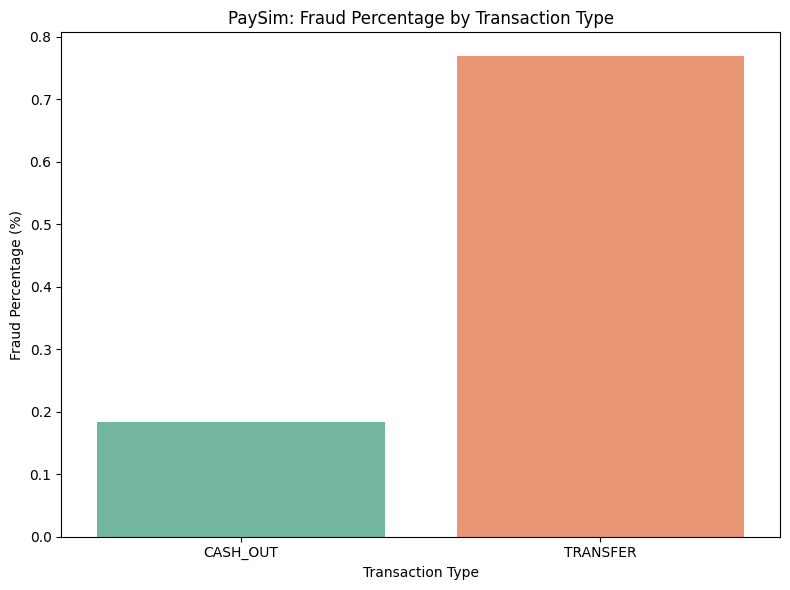

In [ ]:
# PaySim Fraud Percentage by Type
paysim_fraud = fraud_by_type[fraud_by_type['sum'] > 0].reset_index()
sns.barplot(data=paysim_fraud, x='type', y='fraud_percentage', hue='type', ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('PaySim: Fraud Percentage by Transaction Type')
axes[1].set_ylabel('Fraud Percentage (%)')
axes[1].set_xlabel('Transaction Type')

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=paysim_fraud, x='type', y='fraud_percentage', hue='type', palette='Set2', legend=False, ax=ax)
ax.set_title('PaySim: Fraud Percentage by Transaction Type')
ax.set_ylabel('Fraud Percentage (%)')
ax.set_xlabel('Transaction Type')
plt.tight_layout()
plt.show()

Based on this visualization, we see that the heavy majority (almost 80%) of fraudulent transactions occur in transfer type of transactions, with the rest coming from cash_out transactions.

### PaySim Balance Changes and Fraud

We use boxplots to explore the relationship between oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest and amount for fraudulent vs. non-fraudulent transactions in PaySim, especially for 'TRANSFER' and 'CASH_OUT' types.

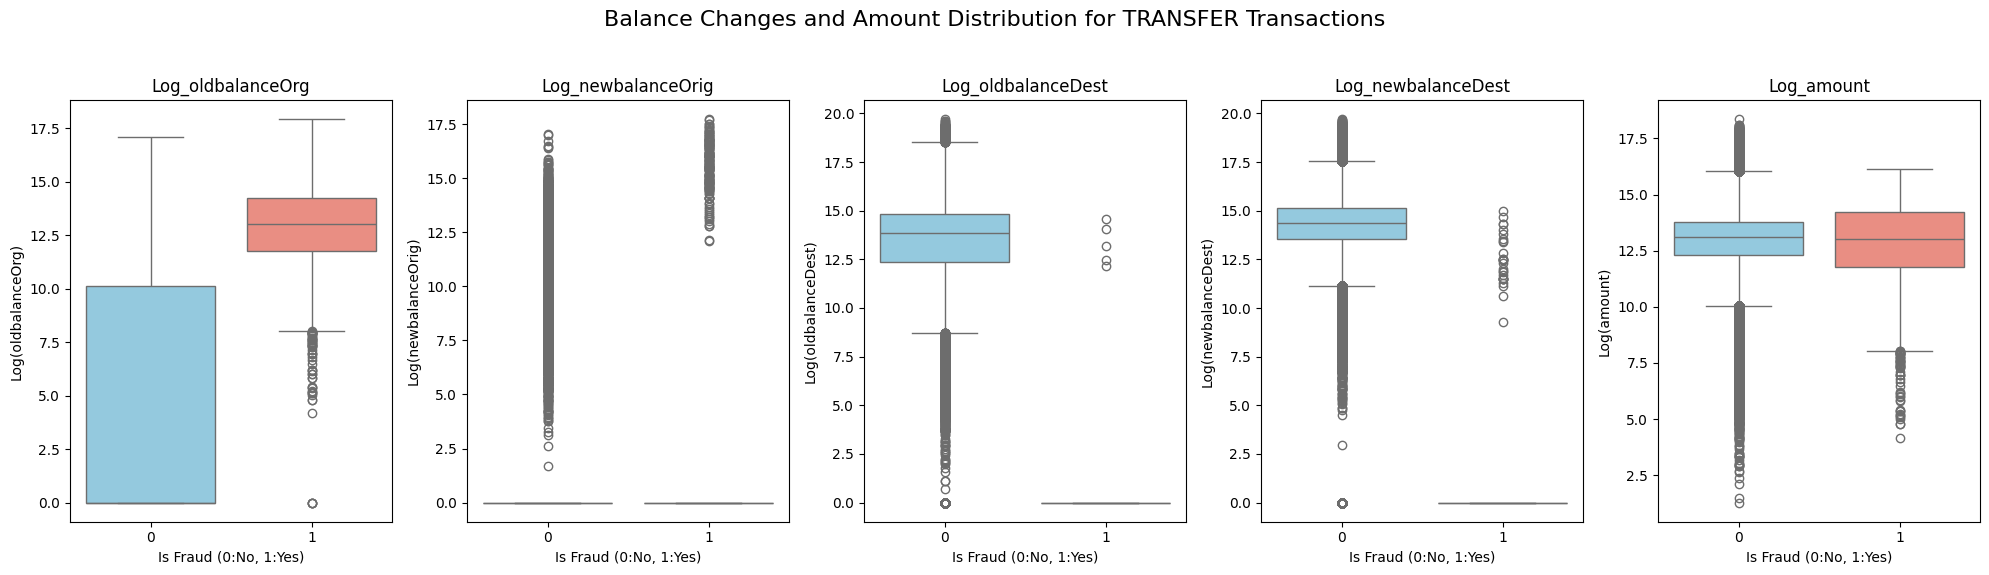

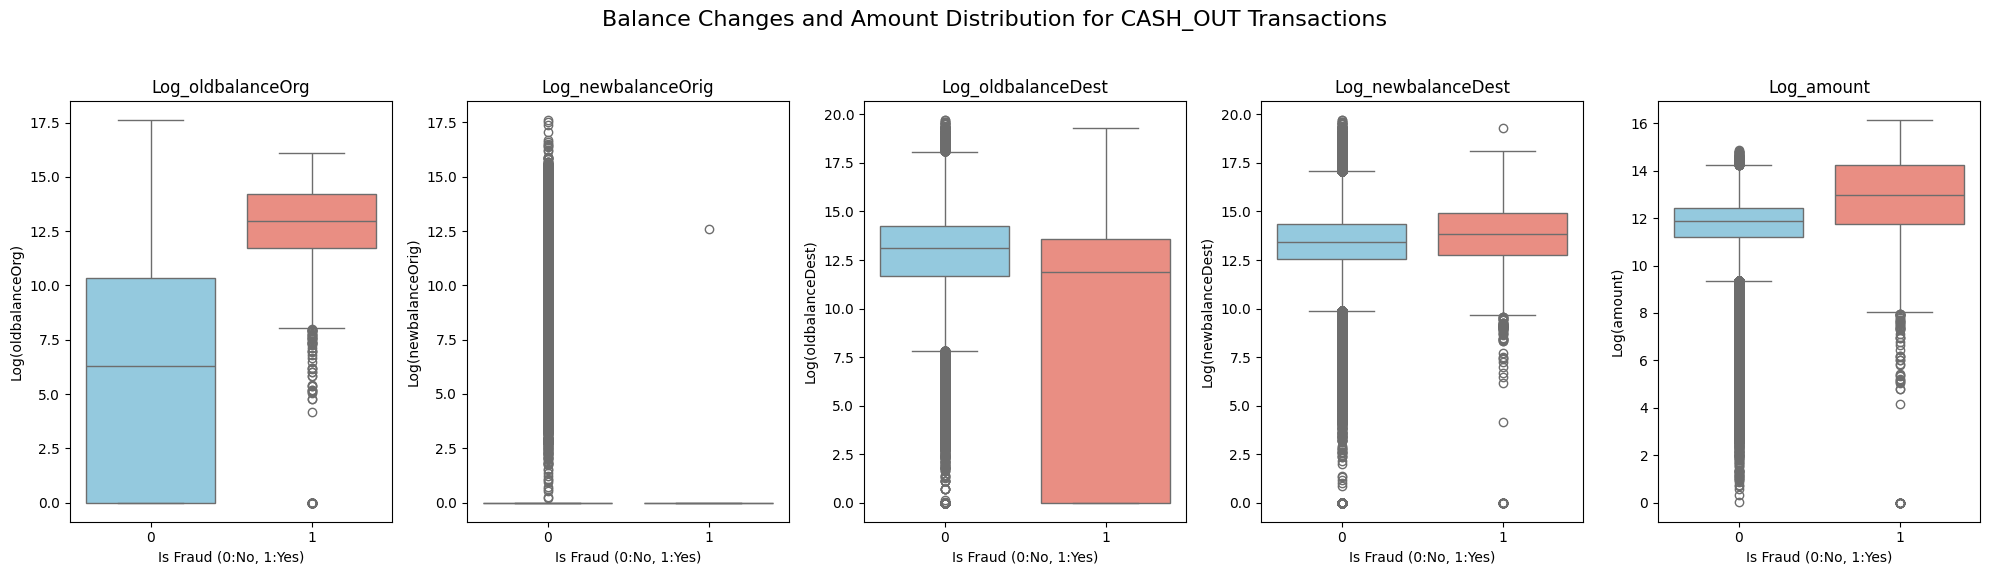

Balance change and amount distribution plots for 'TRANSFER' and 'CASH_OUT' transactions generated.


In [ ]:
# Filter the df_paysim DataFrame to include only 'TRANSFER' and 'CASH_OUT' transaction types.
df_paysim_filtered = df_paysim[df_paysim['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Define the columns for which we want to analyze balance changes and amount
balance_cols = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'amount']

# Apply a logarithmic transformation (e.g., np.log1p) to the 'amount' and balance columns
# and create new columns for the log-transformed values.
for col in balance_cols:
    df_paysim_filtered[f'log_{col}'] = np.log1p(df_paysim_filtered[col])

# For each of these transaction types ('TRANSFER' and 'CASH_OUT'), create a figure with subplots.
for trans_type in ['TRANSFER', 'CASH_OUT']:
    df_subset = df_paysim_filtered[df_paysim_filtered['type'] == trans_type]

    # Create a figure with a subplot for each balance column + amount
    fig, axes = plt.subplots(1, len(balance_cols), figsize=(20, 6))
    fig.suptitle(f'Balance Changes and Amount Distribution for {trans_type} Transactions', fontsize=16)

    # In each subplot, create box plots comparing balance features and amount for fraudulent vs. non-fraudulent transactions.
    for i, col in enumerate(balance_cols):
        sns.boxplot(data=df_subset, x='isFraud', y=f'log_{col}', ax=axes[i], hue='isFraud', palette={0: 'skyblue', 1: 'salmon'}, legend=False)
        axes[i].set_title(f'Log_{col}')
        axes[i].set_xlabel('Is Fraud (0:No, 1:Yes)')
        axes[i].set_ylabel(f'Log({col})')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

print("Balance change and amount distribution plots for 'TRANSFER' and 'CASH_OUT' transactions generated.")

These boxplots give insight to the variance in transaction types across features. Features like amount and newbalance are relatively similar in log amount of transaction types, while oldbalance is skewed towards being more indicative of Fraudulent transactions.

### Graph Design for PaySim (Homogeneous Transaction Graph for GNNs)

The PaySim dataset naturally represents financial interactions as transfers between accounts, which can be modeled as a directed graph. However, to maintain consistency with standard Graph Neural Network architectures such as GCN, GAT, and GraphSAGE, we construct a homogeneous transaction-level graph where nodes correspond to transactions rather than accounts.

In this representation, each node represents a single transaction, which is the unit we aim to classify as fraudulent or non-fraudulent. Node features include transaction-specific attributes such as transaction amount, type (e.g., TRANSFER, CASH_OUT), and temporal information (step), as well as relevant balance features.

Node Definition:

*  **Transaction**: Each node corresponds to a transaction and contains features such as amount, transaction type (encoded), time step, and account balance information. The classification task is performed at the node level.

Edge Construction (Relationships):
Edges are defined between transactions based on shared accounts and temporal relationships, capturing the flow of money through the system. Specifically, edges are created between two transaction nodes if:

*  They share the same origin account (nameOrig)

*  They share the same destination account (nameDest)

*  One transaction’s destination account becomes the origin of another (capturing transaction chains)

These connections allow the graph to encode patterns such as repeated transactions from the same account or sequences of transfers that may indicate fraudulent behavior.

Optionally, edges may incorporate temporal constraints, such as connecting only transactions that occur within a short time window, to better capture rapid sequences often associated with fraud (e.g. TRANSFER followed immediately by CASH_OUT).

By constructing a homogeneous transaction graph, we preserve key relational information while enabling the use of standard GNN architectures. This representation allows models such as GCN, GAT, and GraphSAGE to learn higher-order patterns, including transaction chains, repeated account usage, and localized clusters of suspicious activity. These structural patterns are particularly important for identifying fraud scenarios such as money laundering, where illicit behavior emerges from sequences of transactions rather than isolated events.

## Elliptic Exploration and Graph Design

We explore label distribution in the Elliptic dataset and define its Bitcoin transaction flow graph design.

**Note**: Class "1" represents illicit transactions, while "2" represents licit transactions. Many are "unknown".


In [ ]:
print("Elliptic Class Distribution:")
class_counts = df_elliptic_classes['class'].value_counts()
class_percentages = df_elliptic_classes['class'].value_counts(normalize=True) * 100

elliptic_dist = pd.DataFrame({'Count': class_counts, 'Percentage': class_percentages})
print(elliptic_dist)

Elliptic Class Distribution:
          Count  Percentage
class                      
unknown  157205   77.148634
2         42019   20.620899
1          4545    2.230467


In [ ]:
df_elliptic_known = df_elliptic_classes[df_elliptic_classes['class'] != 'unknown']
known_counts = df_elliptic_known['class'].value_counts()

print("Elliptic Known Class Distribution:")
print(known_counts)

Elliptic Known Class Distribution:
class
2    42019
1     4545
Name: count, dtype: int64


### Visualization of Licit and Illicit Transactions

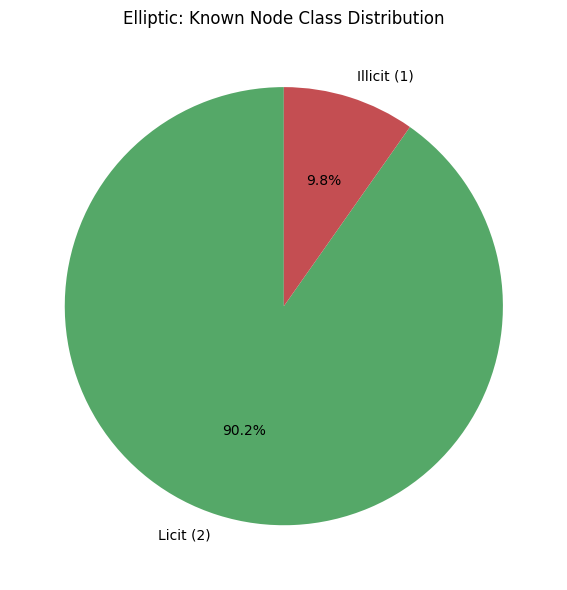

In [ ]:
# Elliptic Class Distribution
axes[2].pie(elliptic_dist['Count'], labels=elliptic_dist.index, autopct='%1.1f%%', startangle=90, colors=['#8C8C8C', '#55A868', '#C44E52'])
axes[2].set_title('Elliptic: Node Class Distribution')

df_elliptic_known = df_elliptic_classes[df_elliptic_classes['class'] != 'unknown']
known_counts = df_elliptic_known['class'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(known_counts, labels=['Licit (2)', 'Illicit (1)'], autopct='%1.1f%%', startangle=90, colors=['#55A868', '#C44E52'])
ax.set_title('Elliptic: Known Node Class Distribution')
plt.tight_layout()
plt.show()

Thus we see Licit transactions dominate the known transaction types, with 90.2% of transactions being classified as Licit. This is relatively lower than expected, which may indicate many "unknown" classes are Licit.

### Elliptic Feature Distributions and Transaction Class

We use histograms overlaid with kernel density estimation (KDE) to examine the distribution of selected features, feature_1, feature_2, feature_10, feature_50, feature_100, and feature_160, for illicit (fraudulent) versus licit (non-fraudulent) transactions in the Elliptic Bitcoin transaction network. These features are spread across the full feature set to represent different aspects of transaction behavior, including local transaction characteristics and aggregated neighborhood features capturing surrounding transaction patterns.

By visualizing the differences in these feature distributions between classes, we gain insight into which attributes are most informative for distinguishing illicit activity. This exploratory analysis informs the subsequent design of Graph Neural Networks, as features exhibiting strong class separation or characteristic patterns are likely to enhance node embeddings and improve fraud detection performance. Sampling is used to make the visualization computationally feasible, while KDE overlays provide smooth estimates of underlying distributions.

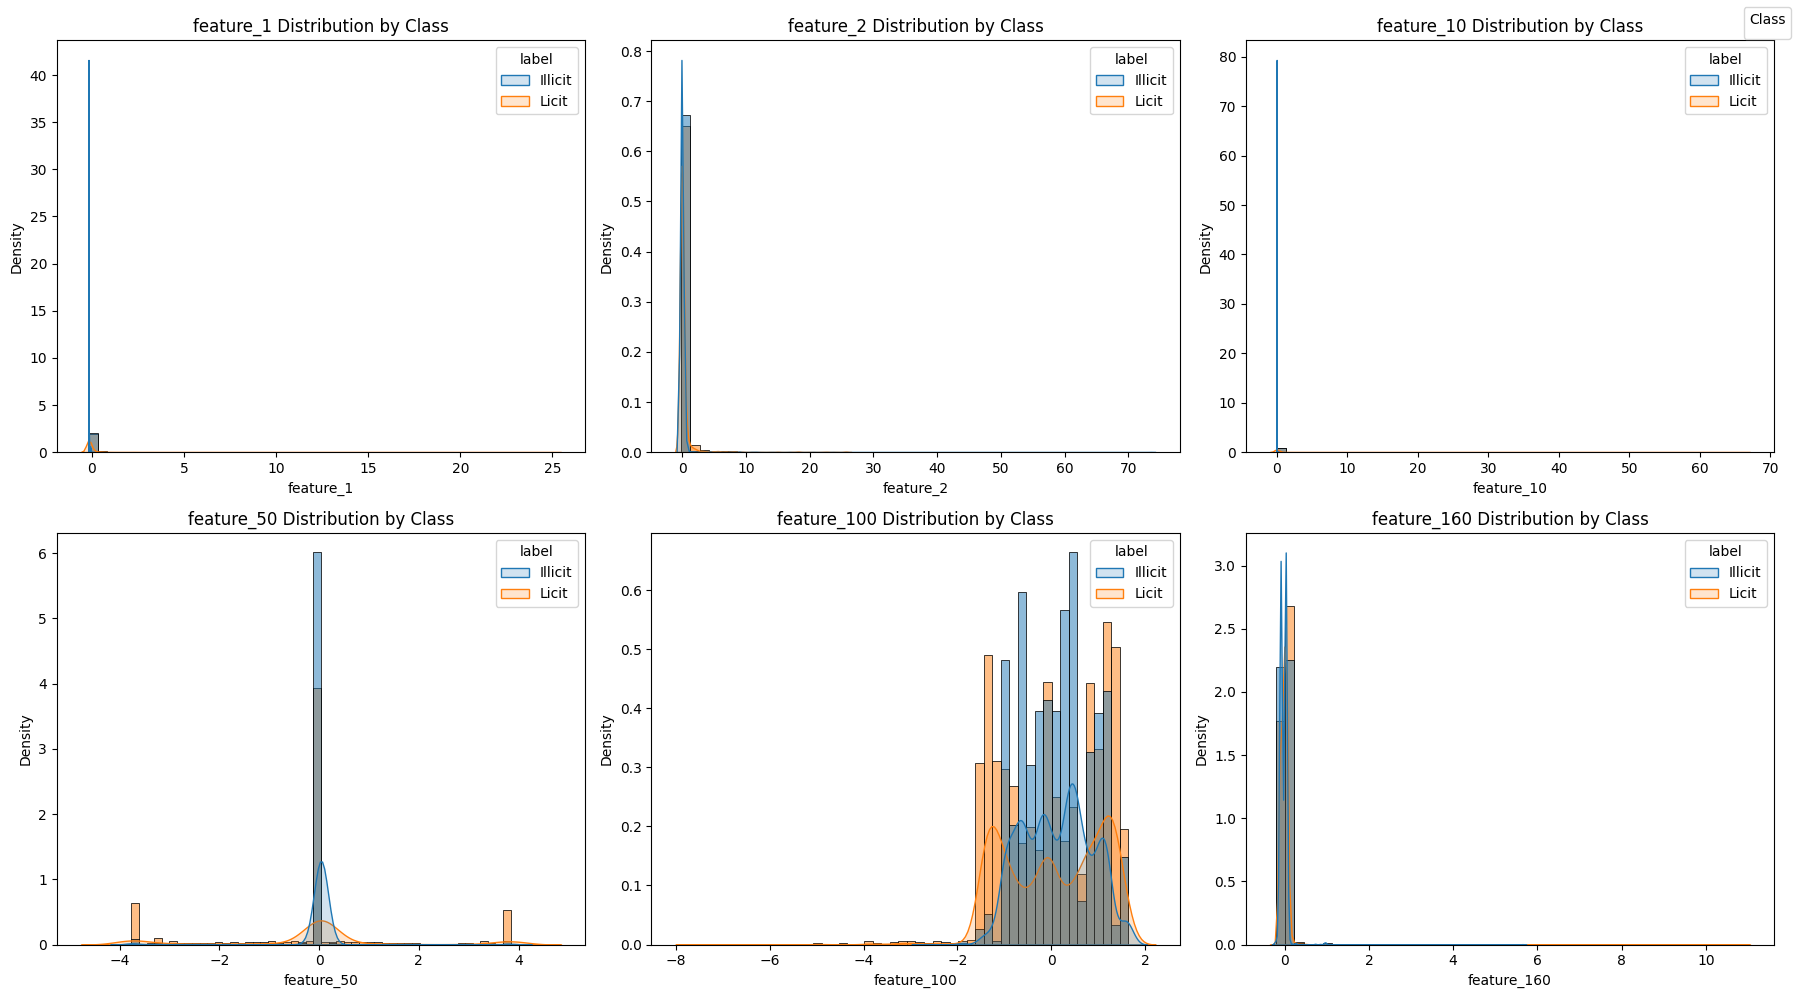

In [ ]:
# Rename Elliptic features
num_cols = df_elliptic_features.shape[1]  # should be 166
feature_cols = [f'feature_{i}' for i in range(1, num_cols-1)]  # feature_1 to feature_164
df_elliptic_features.columns = ['txId', 'timestep'] + feature_cols

# Merge features with class labels
df_elliptic_merged = pd.merge(
    df_elliptic_features,
    df_elliptic_classes,  # should have columns txId, class
    on='txId',
    how='left'
)

# Filter known transactions
df_elliptic_known = df_elliptic_merged[df_elliptic_merged['class'] != 'unknown'].copy()
df_elliptic_known['class'] = df_elliptic_known['class'].astype(int)
df_elliptic_known['label'] = df_elliptic_known['class'].map({1: 'Illicit', 2: 'Licit'})

# Select features for plotting
selected_features = ['feature_1', 'feature_2', 'feature_10', 'feature_50', 'feature_100', 'feature_160']
# Keep only features that exist in the dataframe
selected_features = [f for f in selected_features if f in df_elliptic_known.columns]

# Sample for histogram and KDE
sample_df = df_elliptic_known.groupby('label').sample(n=5000, random_state=42, replace=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    sns.histplot(
        data=sample_df,
        x=feature,
        hue='label',
        stat='density',
        common_norm=False,
        alpha=0.5,
        bins=50,  # fewer bins = faster
        ax=axes[i],
        legend=False
    )

    # Optional KDE overlay
    sns.kdeplot(
        data=sample_df,
        x=feature,
        hue='label',
        fill=True,
        alpha=0.2,
        ax=axes[i]
    )

    axes[i].set_title(f'{feature} Distribution by Class')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], title='Class', loc='upper right')

plt.tight_layout()
plt.show()

The distributions indicate that not all features contribute equally to class separation. Features 1, 2, 10, and 160 are highly skewed and overlap substantially between illicit and licit transactions, offering limited discriminative signal. In contrast, intermediate features like feature_50 and feature_100 exhibit clearer divergence. For example, feature_50 shows multimodal peaks for licit transactions while illicit nodes remain near zero, and feature_100 displays distinct density differences. These variance-rich features are likely to be most informative for the GNN, enabling it to learn robust node embeddings that capture structural and behavioral patterns indicative of fraud.

Graph Design for Elliptic (Transaction Graph for GNNs)

The Elliptic dataset is inherently structured as a graph representing the flow of Bitcoin transactions over time. Unlike other datasets that require graph construction, this dataset directly provides a transaction-level graph, making it naturally compatible with Graph Neural Network architectures such as GCN, GAT, and GraphSAGE.

In this representation, each node corresponds to a Bitcoin transaction, which serves as the unit of classification. The dataset includes a rich set of features for each transaction, capturing both local transaction properties and aggregated information from neighboring transactions.

Node Definition:

*  Transaction: Each node represents a single Bitcoin transaction. Node features include transaction-specific attributes such as timestep, number of inputs and outputs, transaction fees, and precomputed aggregated features derived from the local neighborhood.

Edge Construction (Relationships):
Edges are directed and represent the flow of Bitcoin between transactions. Specifically, an edge is formed from one transaction to another if the output of the first transaction is used as an input to the second. This captures the movement of funds through the network and forms a temporal transaction graph.

These connections allow the model to learn patterns of fund propagation, including transaction chains and branching structures that are often associated with illicit activity.

Labels:

*  Each transaction node is labeled as:

*  Illicit (fraudulent)

*  Licit (non-fraudulent)

*  Unknown (unlabeled)

The primary task is node classification, where the goal is to predict whether a transaction is illicit or licit based on both its features and its position within the graph.

Because the graph structure is explicitly provided, this dataset serves as a strong benchmark for evaluating graph-based models. Graph Neural Networks can effectively leverage the connectivity patterns in the network to identify suspicious behaviors, such as rapid fund transfers across multiple transactions or characteristic subgraph structures associated with money laundering activities.

By using this dataset alongside constructed graphs from other sources, we can evaluate how well GNN models perform when relational structure is directly available versus when it must be inferred, providing valuable insight into the role of graph representation in fraud detection.

## Cross-Dataset Comparison

To effectively leverage Graph Neural Networks, it is essential to understand the structural differences among the chosen datasets and how each is adapted into a graph representation compatible with standard GNN architectures (GCN, GAT, GraphSAGE). The following table summarizes the graph formulation for each dataset:

| Dataset | Graph Structure | Node Type | Edge Definition | Suitability for GNNs |
| :--- | :--- | :--- | :--- | :--- |
| **PaySim** | Homogeneous Transaction Graph | Transaction | Transactions are connected if they share the same origin account, destination account, or form sequential transaction chains | High. Captures transaction flow patterns and sequential behaviors (e.g., TRANSFER → CASH_OUT) commonly associated with fraud. |
| **IEEE-CIS** | Homogeneous Transaction Graph (Projected) | Transaction | Transactions are connected if they share attributes such as card ID, email domain, or device information | High. Enables detection of coordinated fraud patterns such as shared cards or devices across multiple transactions. |
| **Elliptic** | Homogeneous Directed Graph | Transaction | Directed edges represent the flow of Bitcoin between transactions | Very High. Native graph structure allows direct modeling of transaction propagation and illicit activity patterns. |

### Conclusion

Traditional machine learning models often struggle to capture the complex, coordinated nature of financial fraud due to their reliance on independent, tabular representations of transactions. By transforming transaction data into graph structures, we enable the modeling of relational dependencies and higher-order interactions that are otherwise difficult to detect.

In our approach, we construct homogeneous transaction graphs that preserve key relational information across all datasets. This allows us to capture important patterns such as chains of suspicious transfers in PaySim, clusters of transactions linked through shared attributes in IEEE-CIS, and the propagation of illicit funds in the Elliptic Bitcoin network.

By leveraging Graph Neural Networks, we can learn from both node features and graph topology, providing a more expressive framework for fraud detection. With these graph representations defined, the next steps involve systematic data preprocessing, feature engineering, and the implementation of GNN models (GCN, GAT, and GraphSAGE) tailored to each dataset. This unified approach enables a consistent and robust evaluation of graph-based learning across diverse financial environments.